<a href="https://colab.research.google.com/github/Prerna-Karle/Advance-Quantum-Computation/blob/main/P03_Implement_grovers_search_algorithm_for_a_2_qubit_search_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit

In [2]:
!pip install qiskit qiskit-aer

In [3]:
#Import Required Libraries
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit import transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [4]:
#Create Quantum Circuit
qc = QuantumCircuit(2, 2)

In [5]:
#Initialize Superposition
qc.h([0, 1])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [6]:
#Apply Oracle (Mark |11⟩)
qc.cz(0, 1)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [7]:
#Apply Diffusion Operator
# Hadamard
qc.h([0, 1])

# NOT gates
qc.x([0, 1])

# Controlled operation
qc.h(1)
qc.cx(0, 1)
qc.h(1)

# NOT gates again
qc.x([0, 1])

# Hadamard again
qc.h([0, 1])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [8]:
#Measurement
qc.measure([0, 1], [0, 1])

In [9]:
!pip install pylatexenc

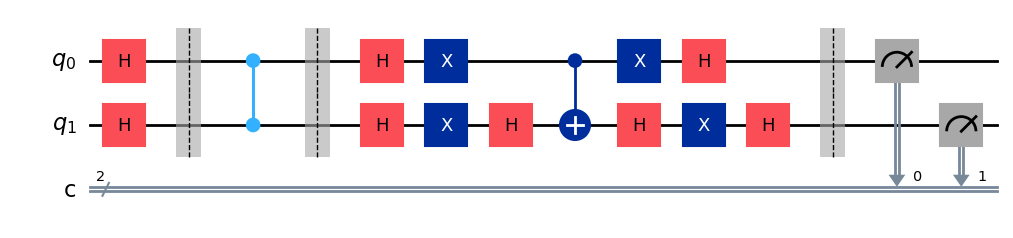

In [10]:
#Draw Circuit
qc.draw('mpl')

In [11]:
#Run the Simulator
simulator = Aer.get_backend('aer_simulator')

qc_compiled = transpile(qc, simulator)

result = simulator.run(qc_compiled, shots=1024).result()
counts = result.get_counts()

{'11': 1024}


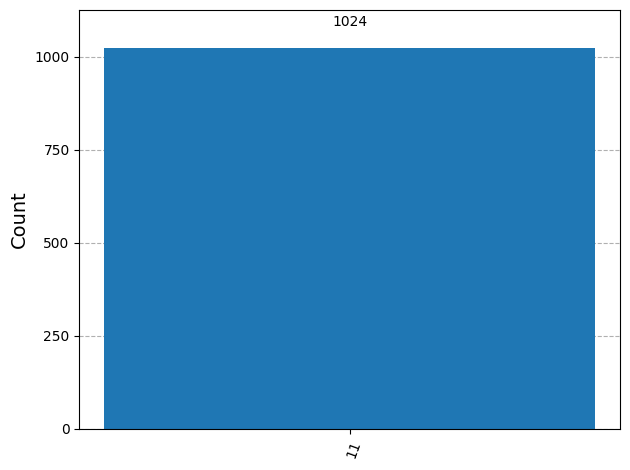

In [14]:
#Display Result
print(counts)
fig = plot_histogram(counts)
display(fig)